In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from scipy import stats

In [2]:
df = pd.read_csv("../data/raw/Video_Games_Sales_as_at_22_Dec_2016.csv")
df

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,Tecmo Koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16715,LMA Manager 2007,X360,2006.0,Sports,Codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16716,Haitaka no Psychedelica,PSV,2016.0,Adventure,Idea Factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16717,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [68]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

In [69]:
print(train_set.shape)
print(test_set.shape)

(13375, 16)
(3344, 16)


In [70]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13375 entries, 9162 to 15795
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             13374 non-null  object 
 1   Platform         13375 non-null  object 
 2   Year_of_Release  13164 non-null  float64
 3   Genre            13374 non-null  object 
 4   Publisher        13333 non-null  object 
 5   NA_Sales         13375 non-null  float64
 6   EU_Sales         13375 non-null  float64
 7   JP_Sales         13375 non-null  float64
 8   Other_Sales      13375 non-null  float64
 9   Global_Sales     13375 non-null  float64
 10  Critic_Score     6507 non-null   float64
 11  Critic_Count     6507 non-null   float64
 12  User_Score       8003 non-null   object 
 13  User_Count       6065 non-null   float64
 14  Developer        8065 non-null   object 
 15  Rating           7946 non-null   object 
dtypes: float64(9), object(7)
memory usage: 1.7+ MB


In [71]:
train_set.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,13164.000000,13375.000000,13375.000000,13375.000000,13375.000000,13375.000000,6507.000000,6507.000000,6065.000000
mean,2006.492859,0.260228,0.142113,0.076176,0.046770,0.525554,68.931151,26.409098,159.203957
std,5.870260,0.754561,0.441869,0.308149,0.180931,1.400984,13.941300,18.997901,536.138868
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,24.000000
75%,2010.000000,0.240000,0.110000,0.030000,0.030000,0.470000,79.000000,36.000000,81.000000
max,2020.000000,29.080000,12.760000,10.220000,10.570000,40.240000,98.000000,113.000000,10665.000000


In [72]:
train_set.isnull().sum()

Name                  1
Platform              0
Year_of_Release     211
Genre                 1
Publisher            42
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       6868
Critic_Count       6868
User_Score         5372
User_Count         7310
Developer          5310
Rating             5429
dtype: int64

In [73]:
train_set.groupby("Year_of_Release")[["Critic_Score", "Critic_Count"]].mean()

,Critic_Score,Critic_Count
Year_of_Release,,
1980.0,NaN,NaN
1981.0,NaN,NaN
1982.0,NaN,NaN
1983.0,NaN,NaN
1984.0,NaN,NaN
1985.0,59.000000,9.000000
1986.0,NaN,NaN
1987.0,NaN,NaN
1988.0,64.000000,75.000000


Gran cantidad de nulos en las features relacionadas con las criticas entre los años 1980 y 1995.
Al tener un gran numero de registros decidimos eliminar los missing values solo en el train

In [74]:
train_set = train_set.dropna(axis=0)

In [75]:
train_set.isnull().sum()

Name               0
Platform           0
Year_of_Release    0
Genre              0
Publisher          0
NA_Sales           0
EU_Sales           0
JP_Sales           0
Other_Sales        0
Global_Sales       0
Critic_Score       0
Critic_Count       0
User_Score         0
User_Count         0
Developer          0
Rating             0
dtype: int64

### EDA

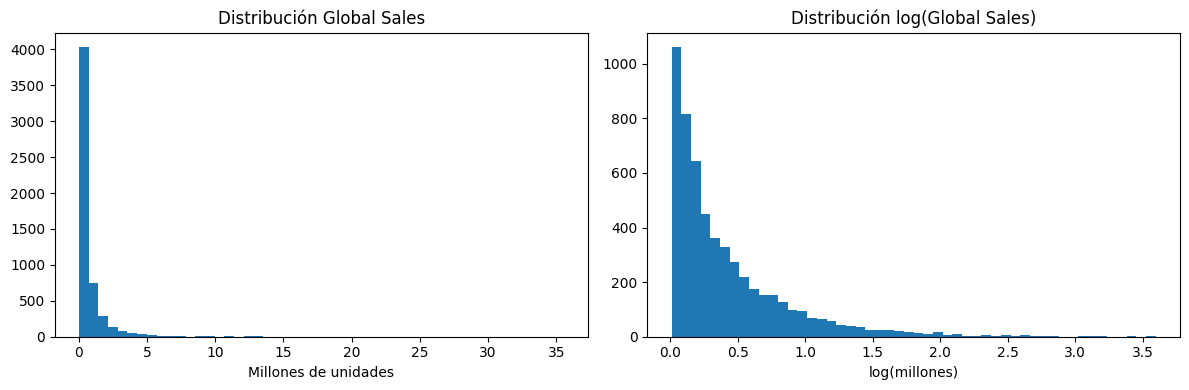

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_set['Global_Sales'], bins=50)
axes[0].set_title('Distribución Global Sales')
axes[0].set_xlabel('Millones de unidades')

axes[1].hist(np.log1p(train_set['Global_Sales']), bins=50)
axes[1].set_title('Distribución log(Global Sales)')
axes[1].set_xlabel('log(millones)')

plt.tight_layout()
plt.show()

In [77]:
train_set['Global_Sales'].describe()

count    5470.000000
mean        0.757525
std         1.624007
min         0.010000
25%         0.110000
50%         0.290000
75%         0.767500
max        35.520000
Name: Global_Sales, dtype: float64

### Distribución de Global_Sales
El target presenta una fuerte asimetría positiva (cola hacia la derecha).
La mayoría de juegos venden menos de 1M de unidades, mientras que unos pocos superan las 5M. Conviene hacer el logaritmo para acercar los valores

In [78]:
genre_sales = round(train_set.groupby("Genre")["Global_Sales"].mean().sort_values(ascending=False), 3)
genre_sales

Genre
Misc            0.946
Shooter         0.935
Platform        0.898
Racing          0.844
Sports          0.766
Action          0.759
Role-Playing    0.687
Fighting        0.681
Simulation      0.678
Puzzle          0.669
Adventure       0.335
Strategy        0.246
Name: Global_Sales, dtype: float64

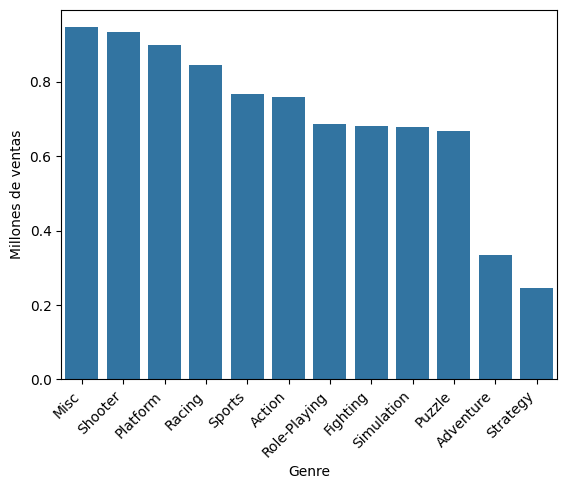

In [79]:
sns.barplot(genre_sales)
plt.ylabel("Millones de ventas")
plt.xticks(rotation= 45, ha= "right");

In [80]:
platform_sales = round(train_set.groupby("Platform")["Global_Sales"].mean().sort_values(ascending=False), 3)
platform_sales

Platform
PS      1.551
Wii     1.079
PS4     1.058
PS3     1.004
X360    0.974
3DS     0.903
DS      0.850
XOne    0.838
PS2     0.823
WiiU    0.672
GBA     0.544
PSP     0.492
GC      0.479
XB      0.381
DC      0.380
PSV     0.277
PC      0.252
Name: Global_Sales, dtype: float64

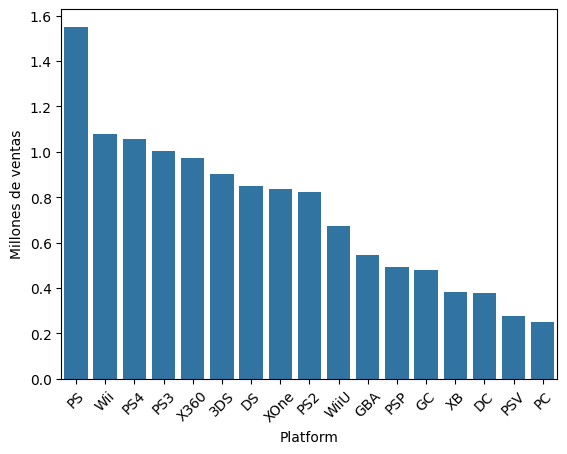

In [82]:
sns.barplot(platform_sales)
plt.ylabel("Millones de ventas")
plt.xticks(rotation= 45, ha= "center");

In [95]:
sales_year = train_set.groupby("Year_of_Release")["Global_Sales"].sum()

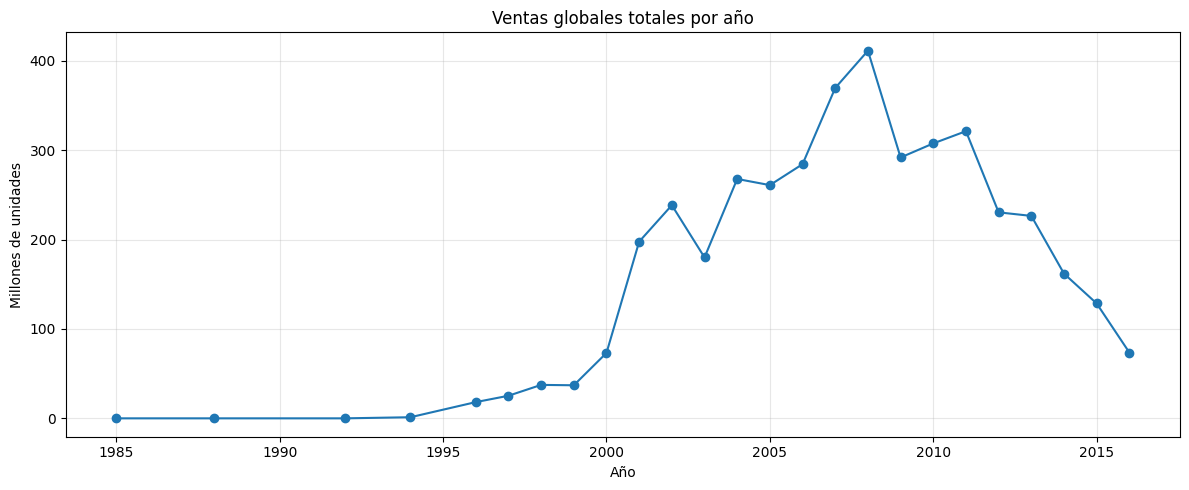

In [91]:
plt.figure(figsize=(12, 5))
sales_year.plot(kind='line', marker='o')
plt.title('Ventas globales totales por año')
plt.ylabel('Millones de unidades')
plt.xlabel('Año')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Observamos una subida en el numero de copias vendidas en el año 2000 llegando a un pico de más de 400 millones de ventas en 2008 que luego decrece por debajo de las 100 millones.

In [98]:
sales_region = train_set[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].mean()

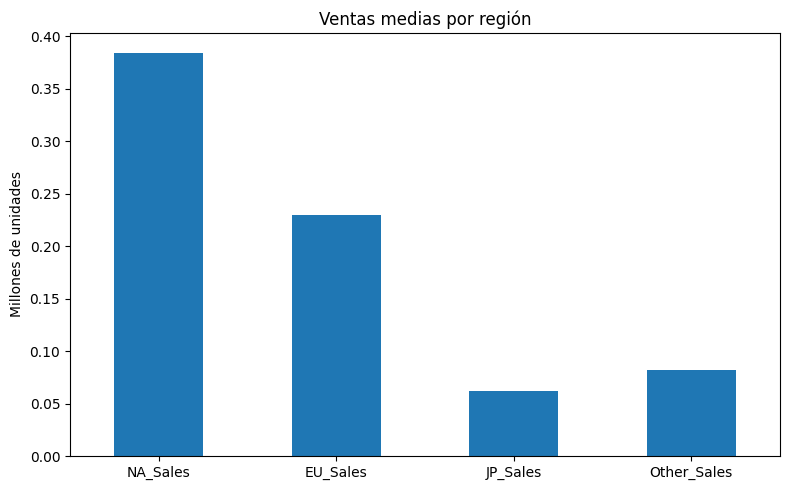

In [99]:
plt.figure(figsize=(8, 5))
sales_region.plot(kind='bar')
plt.title('Ventas medias por región')
plt.ylabel('Millones de unidades')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Axes: xlabel='Critic_Score', ylabel='Global_Sales'>

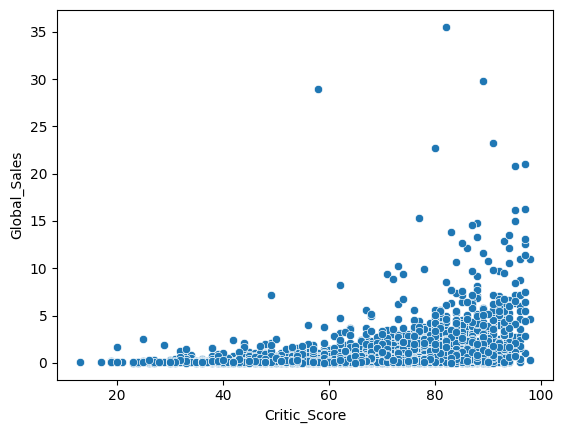

In [102]:
sns.scatterplot(train_set, x="Critic_Score", y="Global_Sales")

In [109]:
train_set.dtypes

Name                object
Platform            object
Year_of_Release    float64
Genre               object
Publisher           object
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count       float64
User_Score         float64
User_Count         float64
Developer           object
Rating              object
dtype: object

In [107]:
train_set["User_Score"] = train_set["User_Score"].astype("float")

<Axes: >

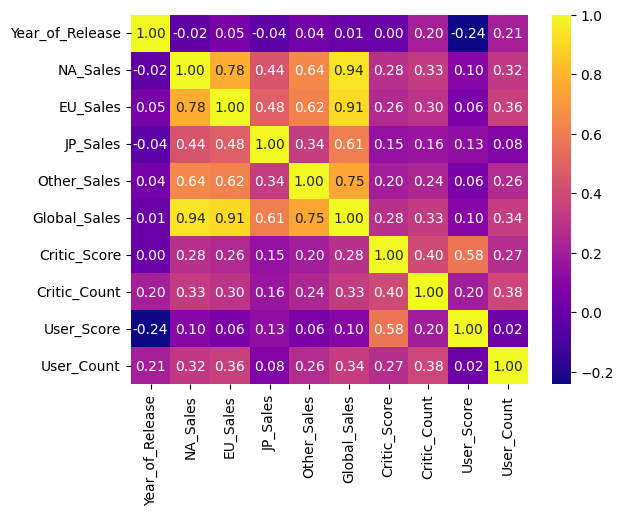

In [119]:
sns.heatmap(train_set.corr(numeric_only=True), annot=True, cmap="plasma", fmt=".2f")

Se observa fuerte colinealidad entre las ventas por region y ventas globales, como es evidente. Al margen de eso, no se aprecian columnas numericas que tengan una buena relacion con nuestro target

## Feature Engineering

En primer lugar, vamos a aplicar el logaritmo a nuestro target en train

In [125]:
from scipy.stats import shapiro, skew

In [127]:
print("Shapiro p-value:", shapiro(train_set["Global_Sales"]).pvalue)
print("Skew:", skew(train_set["Global_Sales"]))

print("Shapiro p-value:", shapiro(np.log1p(train_set["Global_Sales"])).pvalue)
print("Skew:", skew(np.log1p(train_set["Global_Sales"])))


Shapiro p-value: 2.3753272676209496e-86
Skew: 8.304999986579597
Shapiro p-value: 4.15306260820962e-65
Skew: 2.116815086843047


c:\Users\paspe\Desktop\DATA_SCIENCE\ML_project\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5470.
  res = hypotest_fun_out(*samples, **kwds)


In [128]:
train_set["Global_Sales"] = np.log1p(train_set["Global_Sales"])

Categorizamos el año de lanzamiento de videojuego en decadas. Lo aplicamos tanto en train como en test

In [132]:
def create_decades(year):
    if year < 1990:
        return "80s"
    elif year < 2000:
        return "90s"
    elif year < 2010:
        return "2000s"
    else:
        return "2010s"
    
train_set["Decade"] = train_set["Year_of_Release"].apply(create_decades)
test_set["Decade"] = test_set["Year_of_Release"].apply(create_decades)

Hacemos un encoding basado en dummies con las features de Genero, Rating y Decada

In [ ]:
train_set = pd.get_dummies(train_set, columns=['Genre', 'Rating', 'Decade'], drop_first=True)
test_set = pd.get_dummies(test_set, columns=['Genre', 'Rating', 'Decade'], drop_first=True)

In [ ]:
train_set = train_set.replace({True: 1, False: 0})
test_set = test_set.replace({True: 1, False: 0})

,Name,Platform,Year_of_Release,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,...,Genre_Simulation,Genre_Sports,Genre_Strategy,Rating_E10+,Rating_M,Rating_RP,Rating_T,Decade_2010s,Decade_80s,Decade_90s
3307,Dragon Ball Z: Ultimate Tenkaichi,PS3,2011.0,Namco Bandai Games,0.27,0.18,0.09,0.07,0.476234,58.0,...,0,0,0,0,0,0,1,1,0,0
10050,NFL Head Coach 09,X360,2008.0,Electronic Arts,0.11,0.00,0.00,0.01,0.104360,67.0,...,0,1,0,0,0,0,0,0,0,0
7017,Madagascar: Escape 2 Africa,PS3,2008.0,Activision,0.12,0.08,0.00,0.03,0.207014,58.0,...,0,0,0,1,0,0,0,0,0,0
2519,Shin Megami Tensei: Persona 4,PS2,2008.0,Atlus,0.34,0.04,0.36,0.08,0.598837,90.0,...,0,0,0,0,1,0,0,0,0,0
8956,Earth Defense Force 2025,X360,2013.0,D3Publisher,0.06,0.03,0.05,0.01,0.139762,68.0,...,0,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14423,Sorcery Saga: The Curse of the Great Curry God,PSV,2013.0,Rising Star Games,0.00,0.00,0.03,0.00,0.029559,65.0,...,0,0,0,0,0,0,1,1,0,0
4426,Transformers: Fall of Cybertron,X360,2012.0,Activision,0.28,0.12,0.00,0.04,0.364643,79.0,...,0,0,0,0,0,0,1,1,0,0
11964,Grand Kingdom,PS4,2015.0,Nippon Ichi Software,0.03,0.00,0.03,0.01,0.067659,78.0,...,0,0,0,0,0,0,1,1,0,0
5390,Monopoly,PS3,2008.0,Electronic Arts,0.25,0.05,0.00,0.04,0.292670,54.0,...,0,0,0,0,0,0,0,0,0,0


In [142]:
train_set

,Name,Platform,Year_of_Release,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,...,Genre_Simulation,Genre_Sports,Genre_Strategy,Rating_E10+,Rating_M,Rating_RP,Rating_T,Decade_2010s,Decade_80s,Decade_90s
3307,Dragon Ball Z: Ultimate Tenkaichi,PS3,2011.0,Namco Bandai Games,0.27,0.18,0.09,0.07,0.476234,58.0,...,0,0,0,0,0,0,1,1,0,0
10050,NFL Head Coach 09,X360,2008.0,Electronic Arts,0.11,0.00,0.00,0.01,0.104360,67.0,...,0,1,0,0,0,0,0,0,0,0
7017,Madagascar: Escape 2 Africa,PS3,2008.0,Activision,0.12,0.08,0.00,0.03,0.207014,58.0,...,0,0,0,1,0,0,0,0,0,0
2519,Shin Megami Tensei: Persona 4,PS2,2008.0,Atlus,0.34,0.04,0.36,0.08,0.598837,90.0,...,0,0,0,0,1,0,0,0,0,0
8956,Earth Defense Force 2025,X360,2013.0,D3Publisher,0.06,0.03,0.05,0.01,0.139762,68.0,...,0,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14423,Sorcery Saga: The Curse of the Great Curry God,PSV,2013.0,Rising Star Games,0.00,0.00,0.03,0.00,0.029559,65.0,...,0,0,0,0,0,0,1,1,0,0
4426,Transformers: Fall of Cybertron,X360,2012.0,Activision,0.28,0.12,0.00,0.04,0.364643,79.0,...,0,0,0,0,0,0,1,1,0,0
11964,Grand Kingdom,PS4,2015.0,Nippon Ichi Software,0.03,0.00,0.03,0.01,0.067659,78.0,...,0,0,0,0,0,0,1,1,0,0
5390,Monopoly,PS3,2008.0,Electronic Arts,0.25,0.05,0.00,0.04,0.292670,54.0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
top_platforms = train_set["Platform"].value_counts()
top_platforms[top_platforms >= 100]

Platform
PS2     905
X360    705
PS3     612
PC      522
XB      448
Wii     389
DS      358
PSP     330
GC      274
GBA     193
PS4     190
XOne    128
3DS     121
PS      111
Name: count, dtype: int64

In [130]:
train_set["Publisher"].value_counts()

Publisher
Electronic Arts                752
Activision                     400
Ubisoft                        400
Sony Computer Entertainment    255
THQ                            238
                              ... 
Telegames                        1
Popcorn Arcade                   1
Encore                           1
2D Boy                           1
Conspiracy Entertainment         1
Name: count, Length: 239, dtype: int64

In [131]:
train_set["Genre"].value_counts()

Genre
Action          1293
Sports           781
Shooter          695
Role-Playing     567
Racing           474
Platform         323
Misc             318
Fighting         293
Simulation       233
Strategy         208
Adventure        193
Puzzle            92
Name: count, dtype: int64